### Housing data (regression), dataset evaluation report

Target variable is **price** (continuous, regression).

Price range is 75 000 - 7 700 000 USD, some outliers in the high-end.

<hr>

**Variables to drop or to process further**

- **id** can be dropped (no significance in this context, just an identifier field)
- **date** only contains one year of time, if used, needs to be processed by years/months/quarters etc. Since it's only one year of time, can also be dropped.
- **lat, long, zipcode** have be to considered separately, since they are spatial meta information => location of the house
    - location plays a crucial role in house market, but we have to use proper methods in order to use these variables (clustering, distance to city centre etc.)
    - using lat/long as they are is dangerous, because they look like conventional measurements to a ML model, but they are actually coordinates

**Rest of the variables**

- bedrooms
- bathrooms
- sqft_living
- sqft_lot
- floors
- waterfront
- view
- condition
- grade
- sqft_above
- sqft_basement
- yr_built
- yr_renovated
- sqft_lot15

<hr>

**Variable importance and redundancy analysis**

**price** is highly correlated with **grade, sqft_living, sqft_living15 and sqft_above**. (Source: y-data-report). 

**bathrooms** also seem to have a connection to **price**, where as **view** and **floors** seem to have a milder connection.

There might be redundancy in the sqft_columns. For example, **sqft_living = sqft_above + sqft_basement**. This means we have derived variables regarding square footage, containing possibly a considertable amount of redundancy.

**VIF-test for multicollinearity**

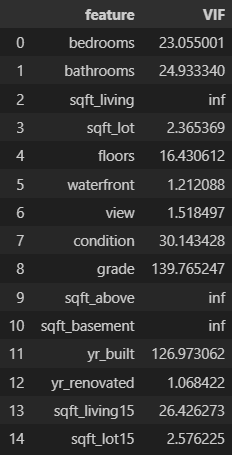

We can see in the VIF-test: **sqft_living, sqft_above and sqft_basement** have positive infinite VIF-test score, implying extreme multicollinearity and redundancy. Few options we can try with these variables:

- Option 1: remove sqft_living and preserve sqft_above and sqft_basement
- Option 2: change sqft_basement to boolean category: (has basement, no basement - 1/0), and remove one of the other variables

<hr>

**Data imbalances**

Variables **waterfront** amd **view** are extremely imbalanced (one-sided). 

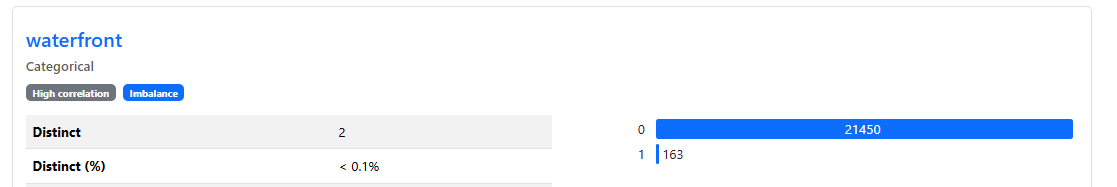

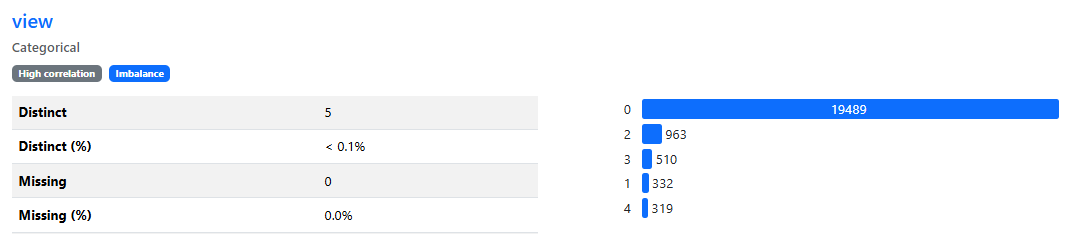

Things to consider for waterfront/view: 

- Approach 1: Under-/oversampling techniques + synthesize more data (CTGAN, CopulaSynthesizer etc)
    - However, the imbalance is so extreme, we might need to consider other options
- Approach 2: We could combine waterfront and view into a single variable, but then again, distributions are so imbalanced, they are almost like outliers (most houses have a bad view), or maybe convert these variables into boolean variables

**sqft_basement and yr_renovated**

**yr_renovated** has a high number of zeroes (~96%). Ideas to try in future:
- combine yr_built and yr_renovated => yr_built_or_last_renovation. The idea is to have the latest year in one column when any kind of construction work was done in this house.

**sqft_basement** has over 60% zero values, indicates many of the houses don't have a basement. Ideas to try:

- convert sqft_basement into a categorical binned variable -> no basement, small basement, average basement, large basement
    - however, boolean variable (no basement/has basement) is probably the best conversion, due to majority of houses not having a basement

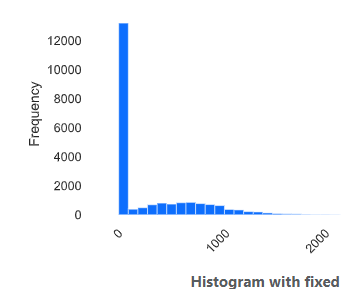

If using **yr_built** either directly or combined with **yr_renovated** => there's a small balance issue in the ataset => more newer than older buildings in the dataset. This is probably natural, since older houses often have to be demolished.

There's also a small gap in 1929 onwards => probably The Great Depression. (due to economy reasons, only few buildings were made.)

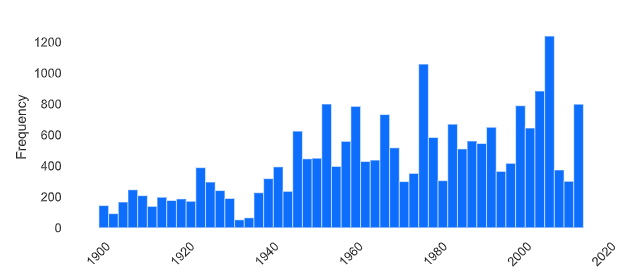

TODO: add floors-variable and ideas on how to combine different values

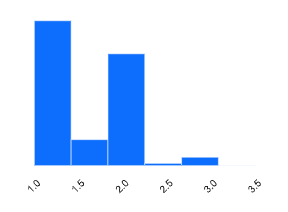

___

**Distributions**

Target variable (price) distribution. Not quite normal distribution, some outliers in the high end. Since this is the target variable of a regression problem, we should aim to optimize (normalize, outlier removal, sampling techniques etc.) this distribution to be close to normal distribution to maximize machine learning model performance.

However, we have to be careful not to over-optimize, so that our model still works with real data as well.

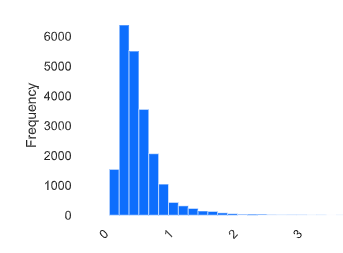

Another idea for optimization - transformation algorithms, for examples (just ideas, asked from ChatGPT):
- Log transformation
- Box-Cox transformation
- Yeo-Johnson transformation
- Quantile transformation
- etc. 

**Support variable distributions**

Support variables are usually not as sensitive on being a normal distribution (or uniform distribution in some cases). As long as the variable has good predictive power (see SHAP/LIME etc.), the distribution can be good. However, if the predictive power is not good, consider optimizing support variable distributions as well.

bathrooms have a sporadic distribution, which is partially due to the system used in US (e.g. 2.5 bathrooms means => 2 full bathrooms (including a shower/bathtub) and 1 bathroom with only toilet and sink (0.5 bathrooms). This variable is probably good to keep in mind, whether we need to simplify the data structure for an easier distribution. 

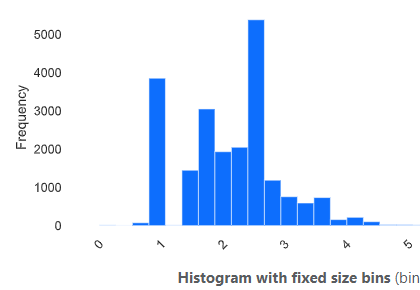

Explanation on the US bathroom amount system:

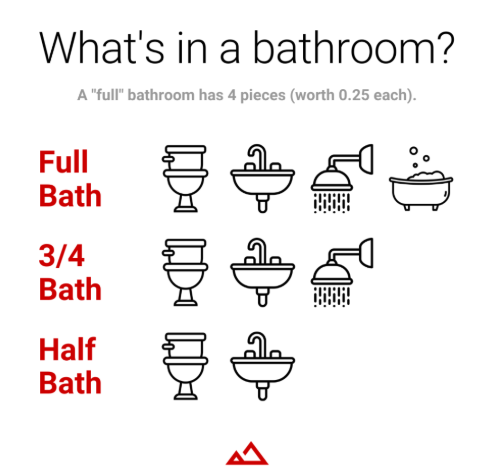

Source: https://danmccurley.com/wp-content/uploads/bathroom-infographic-1024x1024.png

**Based on the picture above**, it might be a good idea to keep the variable as it is for now, since the numeric values (decimals) hide quite a lot of details in them.

bedrooms are quite heavily concentrated, most values being 2-5 bedrooms. This variable probably needs simplifaction and/or outlier removal. Probably good to check this balance again after the outliers in target variable have been removed.

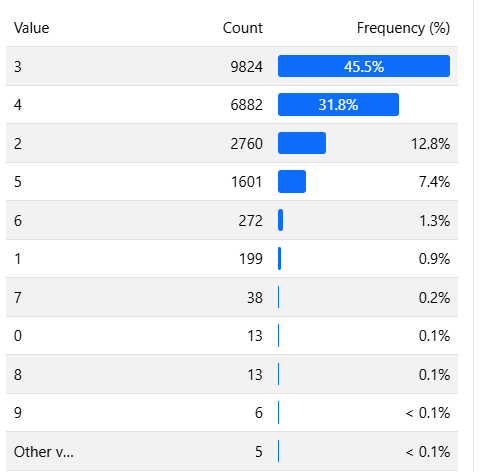

sqft_living is almost normal distribution, only slightly skewed and small amoutn of potential outliers in the high-end. We can probably fix this with sampling techniques or outlier removal later. We can also probably assume most of the larger buildings belong to the most expensive buildings => "fix the price distribution => we also fix this distribution"

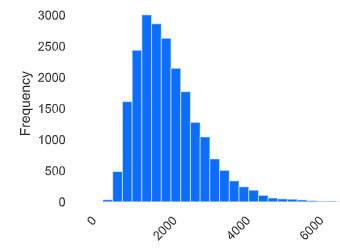

Apparently, the biggest buildings are not the most expensive (but still on the expensive side), but generally in the range of 800k$ - 1.5M$. This is probably due to many luxurious expensive homes tend to be exceedinly big as well.

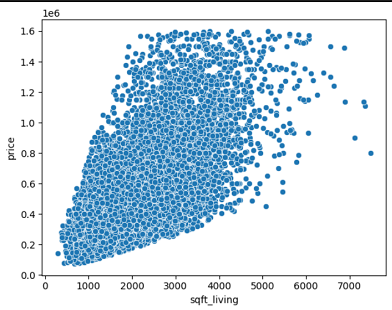

sqft_above has a very similar distribution to sqft_living, we can assume it has a potentially high redundancy. Also some outliers in the high end, probably same houses as in the high-end prices.

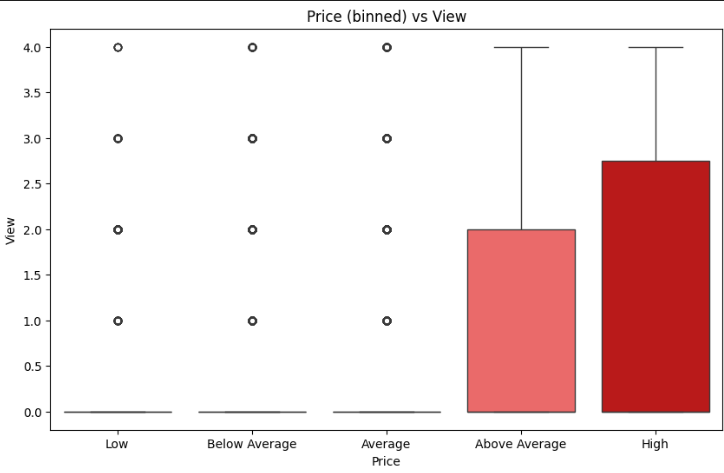

waterfront and view are highly imbalanced, since most buildings don't have a good view or are in front of water. We have either process these variables (combine values for more balanced distribution) or create new data synthetically, or drop the columns altogether. However, since both if these variables might have a very noticeable impact on the target variable, removing is probably not a good option (SHAP, LIME, phik-matrix, etc.)

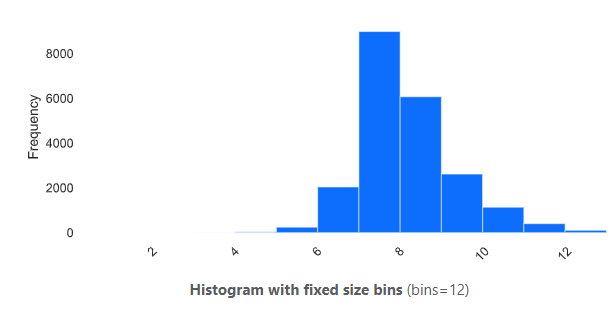

One of the biggest correlating features regarding price, is the grade-column, which is more or less normal distribution already.

___

**Overall trends and irregularities**

___

In order to find irregularities, we are binning the price to a categorical variable (Low, Below Average, Average, Above Average, High))

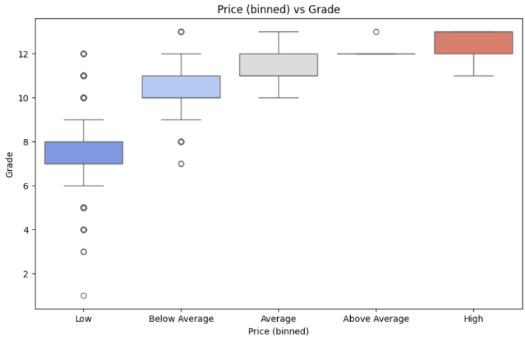

Above we can see the price development towards grade. We can see a clear trend here, although there's a little bit of noise in the low-price -category and a weird distribution in Above Average category.

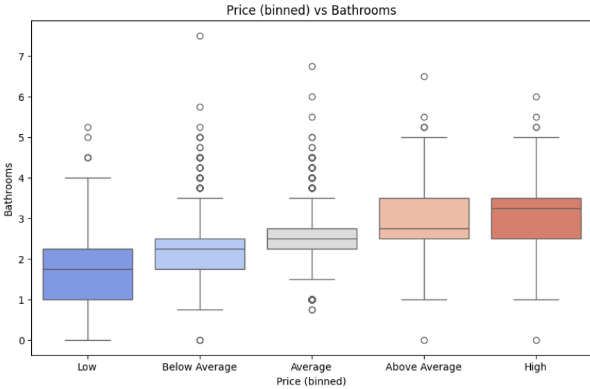

Bathrooms and price have a nice upwards trend, however, some outliers seem to happen, but nothing too much.

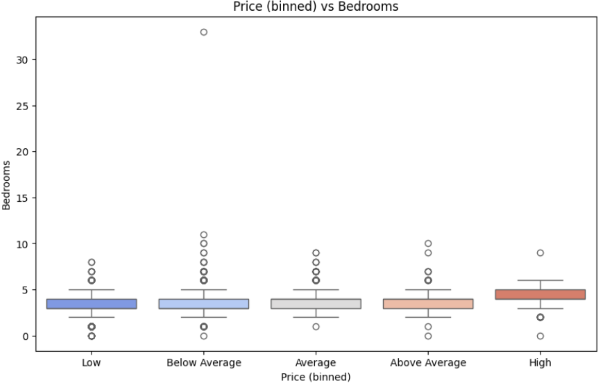

Bedrooms don't really affect the pricing that much. A potential variable for removal later?

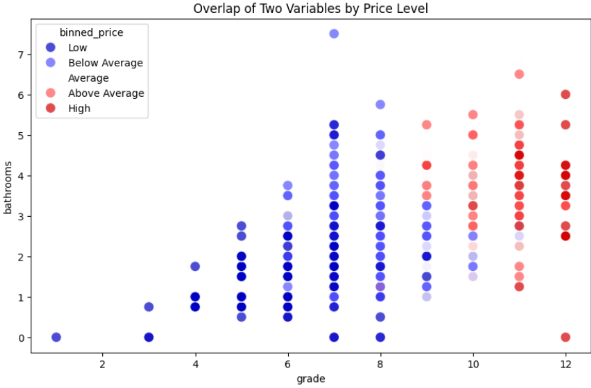

Grade + bathrooms seems to heavily implicate an increase in price. They also separate quite nicely between cheap and expensive houses (good thing for a machine learning model).

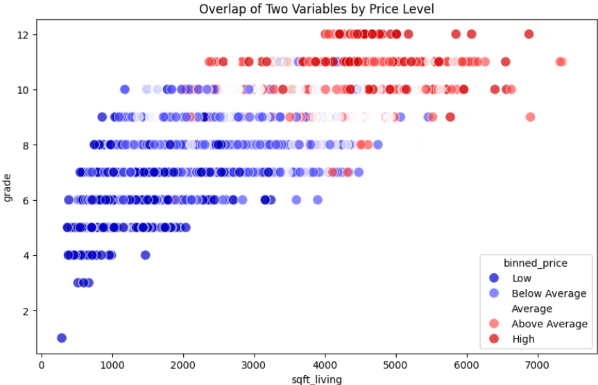

Sqft_living and grade together also affect pricing heavily. Also a fairly good separation between price classes.

### SHAP and LIME for data analysis

NOTE: SHAP and LIME both belong to the domain of Explainable AI

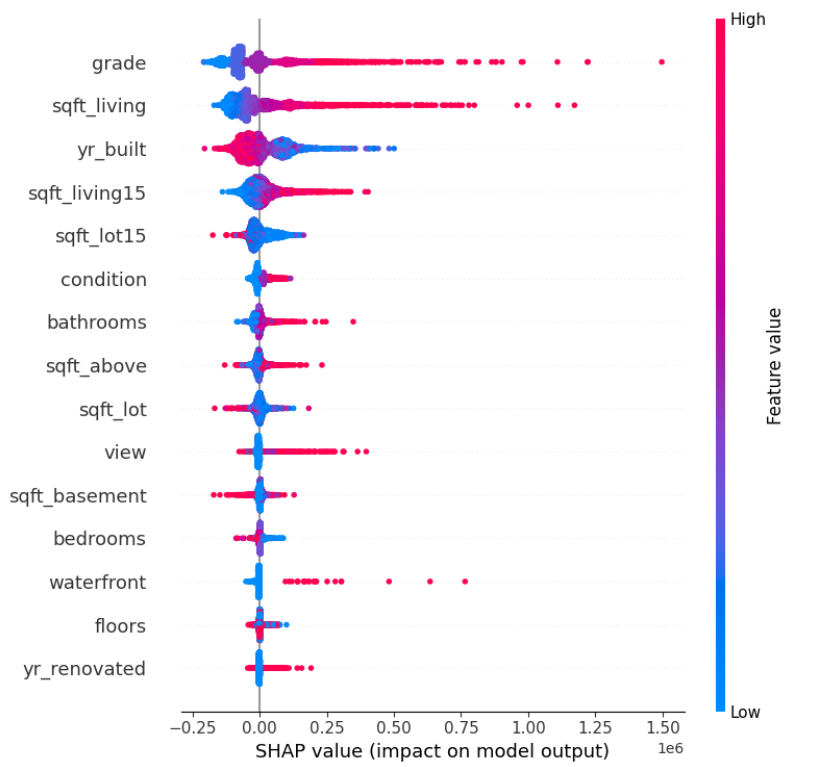

**How to read SHAP:**

- red shapes on the right => as this variable increases, the target increases too (price).
- blue shapes on the right, as this variable decreases, the price increases.
- red shapes on the left, as this variable decreases, the target increases too (price).
- blue shapes on the left, as this variable decreases, the target decreases too (price).

**Optimally you want to have either large shapes (wide) or big ball shapes (heavy impact, but value range is small) => impactful variables**

**If the variable has a small shape concentrating areound SHAP value of 0.0 => not much impact**

The SHAP results align largely with our previous findings. Grade can affect the price both positively and negatively, depending on grade. Also sqft_living (and sqft_living15 of nearby houses) has a huge impact on price both ways. yr_built is a surprisingly impactful variable in the dataset as well.

View and waterfront seem to have a surprisingly high impact on price as well, however, we have to remember both these variables are highly imbalanced in the dataset (most houses are not nest to water and have a bad view).

Many of the variables don't have much impact, like bedrooms, condition, floors (probably since it's linked to house area indirectly), yr_renovated (lots of missing data though).

sqft_basement has a mediocre impact on data, might be related whether a house has a basement or not (supporting our thoughts about converting the basement information into a boolean). sqft_above has a very similar shape as sqft_basement, potentially indicating redundancy in the dataset. 

bathrooms has a surprisingly small effect on price, even though it does have an effect. 

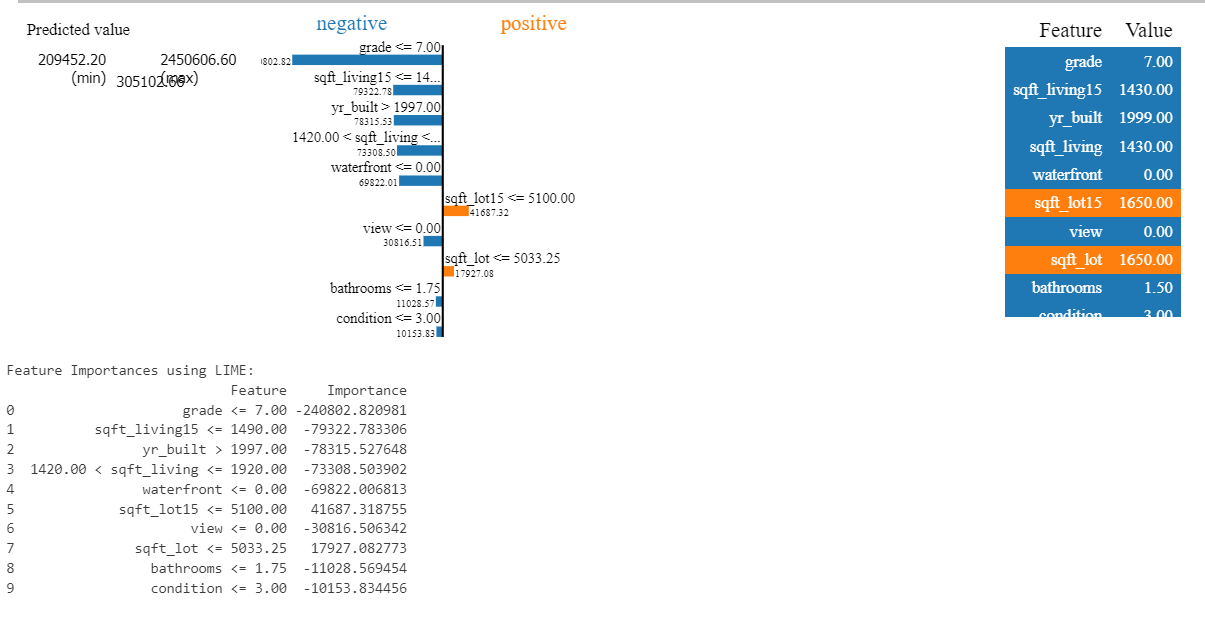

The LIME result indicates the most impactful variables in the dataset to be grade, sqft_living15 (area of nearby houses), yr_built, sqft_living, waterfront, sqft_lot15 (yard area of nearby houses), view, sqft_lot, bathrooms and condition.

In a nutshell, if grade falls 7 or below => it reduces the price heavily. Also, if area of nearby houses falls below 1490 square feet, it also has  a noticeable effect on the price. FOr some reason, if house area falls between 1420 and 1920 square feet, the price falls down (probably the most common house area size).

Newer houses tend to be cheaper too, especially if they are newer than 1997. No waterfront or bad view also affect the price negeatively, even though they are heavily imbalanced variables in the dataset. Less than 1.75 bathrooms and condition less than 3 seem to also reduce the price, even though condition is a very noisy and a seemingly a variable, that doesn't have much impact on price.

Yard size in the neighborhood also seems to increase price, especially if yard is 5100 square feet or less (probably due to farm houses being cheaper due to location, with huge yards).

Yard size of the house itself also follows a similar pattern, however, with less impact than the surrounding houses.

floors is not even mentioned in the LIME result, matching with the SHAP result for less impact in the dataset (probably redundancy)


**NOTE: SHAP and LIME inspect values in with different approaches. SHAP aims to study the dataset on a global scale (how each variable contributes to the whole model) and LIME concentrates more on local variables (each variable studied separately).**

TODO: study the articles in Moodle regarding SHAP/LIME to verify above observations

### Summary of key points:

<ul>
<li>Considerable redundancy in the square_feet -columns</li>
<li>waterfront/view are heavily imbalanced / one-sided, need to balance somehow (syntethic data/oversampling)</li>
<li>sqft_basement has mostly zeroes, might be a good idea to convert into category (no basement, has basement)</li>
<li>yr_renovated + yr_built should be tried to be combined (yr_built_or_last_renovated)</li>
<li>Target variable distribution is non-optimal, but since we have quite a lot of data, fix with undersampling</li>
<li>Independent variable distributions seem ok for now, although, bathrooms has a slightly sporadic distirbution</li>
<li>grade + bathrooms (potentially other independent variable as well) are slightly noisy and have outliers</Li>
<li>sqft_lot information is controversial, sometimes regarded as important and sometimes not</li>
</ul>